# Dạy máy tính nhận biết tài xế tỉnh táo, buồn ngủ hoặc đang ngáp

Notebook này được sắp xếp để có thể chạy lần lượt bằng **Runtime → Run all** trên Google Colab.

**Luồng kỹ thuật:** Mount Google Drive → chuẩn bị YOLO dataset → chuyển sang CNN classification dataset → tạo `tf.data.Dataset` → transfer learning với MobileNetV2 → fine-tuning → đánh giá → lưu model.

**Quy ước nhãn nguồn:** `0=closed_eye`, `1=open_eye`, `2=yawning`.

**Quy ước đầu ra của model:** `0=alert`, `1=drowsy`, `2=yawning`.


## 1. Chuẩn bị nơi lưu dữ liệu và mã nguồn

**Phần kỹ thuật:** Mount Google Drive, tạo các biến `Path` dùng chung và đặt workspace tại `/content/drive/MyDrive/programming/nckh`. Tất cả dataset, checkpoint và model đều được suy ra từ một đường dẫn gốc để tránh trỏ nhầm thư mục.


In [23]:
from google.colab import drive
from pathlib import Path
import json
import os
import random
import shutil
import tempfile

drive.mount("/content/drive")

SEED = 42
KAGGLE_DATASET_ID = "aryansharma8911/open-closed-eyes-and-yawning-labelled"
random.seed(SEED)

WORKSPACE_DIR = Path("/content/drive/MyDrive/programming/nckh")
PROJECT_DIR = WORKSPACE_DIR / "Real-time-driver-drowsiness-detection"

DATA_ROOT = WORKSPACE_DIR / "driver_drowsiness"
DATASET_ARCHIVE_PATH = DATA_ROOT / "archive.zip"
YOLO_DATASET_DIR = DATA_ROOT / "merged_dataset"
CNN_DATASET_DIR = DATA_ROOT / "cnn_dataset"

MODEL_PATH = PROJECT_DIR / "driver_drowsiness_cnn.h5"
FINAL_KERAS_PATH = PROJECT_DIR / "driver_drowsiness_cnn.keras"
STAGE1_CHECKPOINT = PROJECT_DIR / "best_stage1_model.keras"
FINETUNE_CHECKPOINT = PROJECT_DIR / "best_finetuned_model.keras"
CLASS_MAP_PATH = PROJECT_DIR / "class_names.json"

for directory in (WORKSPACE_DIR, PROJECT_DIR, DATA_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

os.chdir(WORKSPACE_DIR)

print("Workspace:", WORKSPACE_DIR)
print("Project:", PROJECT_DIR)
print("YOLO dataset:", YOLO_DATASET_DIR)
print("CNN dataset:", CNN_DATASET_DIR)
print("Final model:", MODEL_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Workspace: /content/drive/MyDrive/programming/nckh
Project: /content/drive/MyDrive/programming/nckh/Real-time-driver-drowsiness-detection
YOLO dataset: /content/drive/MyDrive/programming/nckh/driver_drowsiness/merged_dataset
CNN dataset: /content/drive/MyDrive/programming/nckh/driver_drowsiness/cnn_dataset
Final model: /content/drive/MyDrive/programming/nckh/Real-time-driver-drowsiness-detection/driver_drowsiness_cnn.h5


## 2. Chuẩn bị các công cụ cần thiết

**Phần kỹ thuật:** Kiểm tra TensorFlow có sẵn trong Colab và cài các package còn thiếu bằng `pip`, gồm `kagglehub`, `PyYAML`, `scikit-learn`, `seaborn` và `matplotlib`. Không ghim TensorFlow `2.16.1` vì runtime Python mới không còn bản cài tương thích.


In [24]:
import importlib.util
import subprocess
import sys

packages = [
    "kagglehub",
    "pyyaml",
    "scikit-learn",
    "seaborn",
    "matplotlib",
]

# Google Colab thường đã có TensorFlow. Chỉ cài bản tương thích mới nhất
# khi runtime hiện tại chưa cung cấp package này.
if importlib.util.find_spec("tensorflow") is None:
    packages.append("tensorflow")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    *packages,
])

print("Đã chuẩn bị xong các thư viện cần thiết.")


Đã chuẩn bị xong các thư viện cần thiết.


In [25]:
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import yaml

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 3. Tải bộ ảnh dùng để dạy mô hình

**Phần kỹ thuật:** Dùng `kagglehub.dataset_download()` để tải bản mới nhất của dataset `aryansharma8911/open-closed-eyes-and-yawning-labelled`. `kagglehub` lưu dataset trong bộ nhớ cache của runtime và trả về đường dẫn chứa các file đã tải.


In [26]:
# @title Tải dataset từ Kaggle khi Drive chưa có dữ liệu
from pathlib import Path

KAGGLE_DATASET_ID = "aryansharma8911/open-closed-eyes-and-yawning-labelled"


def drive_yolo_dataset_is_complete(path: Path) -> bool:
    return (
        (path / "dataset.yaml").is_file()
        and all(
            (path / split / part).is_dir()
            for split in ("train", "val", "test")
            for part in ("images", "labels")
        )
    )


KAGGLE_DOWNLOAD_DIR = None
if drive_yolo_dataset_is_complete(YOLO_DATASET_DIR):
    print("Dataset YOLO đã có đầy đủ trên Google Drive; bỏ qua tải Kaggle.")
else:
    import kagglehub

    print("Đang tải dataset từ Kaggle:", KAGGLE_DATASET_ID)
    path = kagglehub.dataset_download(KAGGLE_DATASET_ID)
    KAGGLE_DOWNLOAD_DIR = Path(path)
    print("Path to dataset files:", KAGGLE_DOWNLOAD_DIR)


Dataset YOLO đã có đầy đủ trên Google Drive; bỏ qua tải Kaggle.


### Đưa đầy đủ ảnh và nhãn vào đúng thư mục làm việc

**Phần kỹ thuật:** Đồng bộ riêng từng thư mục `images` và `labels` của `train`, `val`, `test` từ Kaggle sang `YOLO_DATASET_DIR`. Cell so sánh số file, bỏ qua phần đã đủ, tiếp tục phần còn thiếu và in tiến độ sau mỗi 1.000 file; `archive.zip` vẫn là nguồn dự phòng.


In [27]:
YOLO_SPLITS = ("train", "val", "test")
YOLO_PARTS = ("images", "labels")


def looks_like_yolo_dataset(path: Path) -> bool:
    return (
        (path / "dataset.yaml").is_file()
        and all(
            (path / split / part).is_dir()
            for split in YOLO_SPLITS
            for part in YOLO_PARTS
        )
    )


def find_yolo_datasets(search_root: Path):
    return [
        yaml_path.parent
        for yaml_path in search_root.rglob("dataset.yaml")
        if looks_like_yolo_dataset(yaml_path.parent)
    ]


def regular_files(path: Path):
    if not path.is_dir():
        return []
    return sorted(item for item in path.iterdir() if item.is_file())


def sync_directory(source_dir: Path, destination_dir: Path, title: str):
    source_files = regular_files(source_dir)
    if not source_files:
        raise RuntimeError(f"Nguồn không có file: {source_dir}")

    destination_dir.mkdir(parents=True, exist_ok=True)
    existing_names = {item.name for item in regular_files(destination_dir)}
    missing_files = [
        item for item in source_files if item.name not in existing_names
    ]

    print(
        f"{title}: nguồn={len(source_files)}, "
        f"đã có={len(existing_names)}, cần chép={len(missing_files)}",
        flush=True,
    )

    for index, source_file in enumerate(missing_files, start=1):
        shutil.copy2(source_file, destination_dir / source_file.name)
        if index % 1000 == 0 or index == len(missing_files):
            print(
                f"  Đã chép {index}/{len(missing_files)} file còn thiếu",
                flush=True,
            )

    final_count = len(regular_files(destination_dir))
    if final_count != len(source_files):
        raise RuntimeError(
            f"Đồng bộ chưa hoàn tất cho {title}: "
            f"nguồn={len(source_files)}, đích={final_count}"
        )
    print(f"  Hoàn tất {title}: {final_count} file", flush=True)


def sync_yolo_dataset(source_root: Path, source_name: str):
    if not looks_like_yolo_dataset(source_root):
        raise RuntimeError(f"Nguồn YOLO không hợp lệ: {source_root}")

    YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy2(
        source_root / "dataset.yaml",
        YOLO_DATASET_DIR / "dataset.yaml",
    )

    print(f"Đồng bộ dataset từ {source_name}", flush=True)
    print(f"Nguồn: {source_root}", flush=True)
    print(f"Đích: {YOLO_DATASET_DIR}", flush=True)

    for split in YOLO_SPLITS:
        for part in YOLO_PARTS:
            sync_directory(
                source_root / split / part,
                YOLO_DATASET_DIR / split / part,
                title=f"{split}/{part}",
            )

    if not looks_like_yolo_dataset(YOLO_DATASET_DIR):
        raise RuntimeError("Dataset đích vẫn thiếu images hoặc labels.")
    print("Đã đồng bộ đầy đủ dataset YOLO vào Google Drive.", flush=True)


kaggle_source = globals().get("KAGGLE_DOWNLOAD_DIR")
if kaggle_source is not None and Path(kaggle_source).is_dir():
    candidates = find_yolo_datasets(Path(kaggle_source))
    if len(candidates) != 1:
        raise RuntimeError(
            f"Cần đúng một dataset YOLO từ Kaggle, tìm thấy: {candidates}"
        )
    sync_yolo_dataset(
        candidates[0],
        source_name=f"Kaggle:{KAGGLE_DATASET_ID}",
    )
elif looks_like_yolo_dataset(YOLO_DATASET_DIR):
    print("Dataset trên Drive đã có đủ cấu trúc:", YOLO_DATASET_DIR)
elif DATASET_ARCHIVE_PATH.is_file():
    print("Không có dữ liệu Kaggle trong runtime; dùng ZIP:", DATASET_ARCHIVE_PATH)
    with tempfile.TemporaryDirectory(
        prefix="drowsiness_extract_", dir="/content"
    ) as temporary_directory:
        temporary_directory = Path(temporary_directory)
        shutil.unpack_archive(DATASET_ARCHIVE_PATH, temporary_directory)
        candidates = find_yolo_datasets(temporary_directory)
        if len(candidates) != 1:
            raise RuntimeError(
                f"Cần đúng một dataset YOLO trong ZIP, tìm thấy: {candidates}"
            )
        sync_yolo_dataset(candidates[0], source_name=str(DATASET_ARCHIVE_PATH))
else:
    raise RuntimeError(
        "Dataset trên Drive chưa đầy đủ. Hãy chạy cell tải Kaggle trước, "
        f"hoặc đặt file ZIP tại {DATASET_ARCHIVE_PATH}."
    )


Dataset trên Drive đã có đủ cấu trúc: /content/drive/MyDrive/programming/nckh/driver_drowsiness/merged_dataset


## 4. Kiểm tra bộ ảnh có đầy đủ và đúng tên không

**Phần kỹ thuật:** Xác thực ba split `train`, `val`, `test`, kiểm tra từng thư mục `images/labels`, đọc `dataset.yaml` và đối chiếu class ID YOLO. Pipeline dừng sớm nếu dữ liệu thiếu hoặc thứ tự nhãn không phải `closed_eye`, `open_eye`, `yawning`.


In [28]:
SPLITS = ("train", "val", "test")
SOURCE_CLASS_NAMES = ["closed_eye", "open_eye", "yawning"]
YOLO_TO_PROJECT = {
    0: "drowsy",   # closed_eye
    1: "alert",    # open_eye
    2: "yawning",  # yawning
}
CLASS_NAMES = ["alert", "drowsy", "yawning"]

with open(YOLO_DATASET_DIR / "dataset.yaml", encoding="utf-8") as handle:
    dataset_config = yaml.safe_load(handle)

yaml_names = dataset_config.get("names")
if isinstance(yaml_names, dict):
    yaml_names = [yaml_names[index] for index in sorted(yaml_names)]

if yaml_names != SOURCE_CLASS_NAMES:
    raise ValueError(
        f"Thứ tự lớp trong dataset.yaml là {yaml_names}, "
        f"nhưng pipeline yêu cầu {SOURCE_CLASS_NAMES}."
    )

source_rows = []
for split in SPLITS:
    image_dir = YOLO_DATASET_DIR / split / "images"
    label_dir = YOLO_DATASET_DIR / split / "labels"
    if not image_dir.is_dir() or not label_dir.is_dir():
        raise FileNotFoundError(
            f"Thiếu images hoặc labels của split '{split}': {YOLO_DATASET_DIR / split}"
        )
    source_rows.append({
        "split": split,
        "images": sum(item.is_file() for item in image_dir.iterdir()),
        "labels": sum(item.suffix.lower() == ".txt" for item in label_dir.iterdir()),
    })

source_summary = pd.DataFrame(source_rows)
display(source_summary)
print("Nhãn YOLO:", yaml_names)
print("Ánh xạ sang model:", YOLO_TO_PROJECT)


,split,images,labels
0,train,33365,33365
1,val,5477,5477
2,test,5627,5627


Nhãn YOLO: ['closed_eye', 'open_eye', 'yawning']
Ánh xạ sang model: {0: 'drowsy', 1: 'alert', 2: 'yawning'}


## 5. Sắp xếp ảnh vào ba trạng thái của tài xế

**Phần kỹ thuật:** Chuyển annotation YOLO thành cấu trúc thư mục dành cho CNN classification: `alert`, `drowsy`, `yawning`. Với ảnh có nhiều nhãn, độ ưu tiên là `yawning > drowsy > alert`; mỗi split được đánh dấu bằng `_conversion_complete.json` để phát hiện lần chuyển đổi bị gián đoạn. Cell ưu tiên đọc từ cache Kaggle local của Colab để nhanh hơn, in tiến độ sau mỗi 500 ảnh và tiếp tục các ảnh còn thiếu nếu chạy lại.

Đặt `REBUILD_CNN_DATASET=True` khi muốn tạo lại toàn bộ dữ liệu CNN.


In [29]:
from time import monotonic

REBUILD_CNN_DATASET = False
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CLASS_PRIORITY = {1: 1, 0: 2, 2: 3}  # open < closed < yawn
PROGRESS_EVERY = 500  # In tiến độ sau mỗi 500 ảnh.


def choose_image_class(label_path: Path):
    class_ids = set()
    for line in label_path.read_text(encoding="utf-8").splitlines():
        fields = line.split()
        if not fields:
            continue
        class_id = int(float(fields[0]))
        if class_id in YOLO_TO_PROJECT:
            class_ids.add(class_id)

    if not class_ids:
        return None, False

    selected_id = max(class_ids, key=CLASS_PRIORITY.get)
    return YOLO_TO_PROJECT[selected_id], len(class_ids) > 1


def split_is_ready(split_dir: Path) -> bool:
    return (split_dir / "_conversion_complete.json").is_file() and all(
        (split_dir / class_name).is_dir()
        and any((split_dir / class_name).iterdir())
        for class_name in CLASS_NAMES
    )


def find_local_yolo_dataset(search_root: Path):
    candidates = []
    for yaml_path in search_root.rglob("dataset.yaml"):
        dataset_root = yaml_path.parent
        if all(
            (dataset_root / split / part).is_dir()
            for split in SPLITS
            for part in ("images", "labels")
        ):
            candidates.append(dataset_root)
    return candidates


CONVERSION_SOURCE_DIR = YOLO_DATASET_DIR
kaggle_cache_dir = globals().get("KAGGLE_DOWNLOAD_DIR")
if kaggle_cache_dir is not None and Path(kaggle_cache_dir).is_dir():
    cache_candidates = find_local_yolo_dataset(Path(kaggle_cache_dir))
    if len(cache_candidates) == 1:
        CONVERSION_SOURCE_DIR = cache_candidates[0]

if CONVERSION_SOURCE_DIR == YOLO_DATASET_DIR:
    print("Nguồn chuyển đổi: Google Drive (có thể chậm).", flush=True)
else:
    print("Nguồn chuyển đổi: cache Kaggle local của Colab (nhanh hơn).", flush=True)
print(f"Đường dẫn nguồn: {CONVERSION_SOURCE_DIR}", flush=True)


if REBUILD_CNN_DATASET and CNN_DATASET_DIR.exists():
    print("Đang xóa cnn_dataset cũ để tạo lại từ đầu...", flush=True)
    shutil.rmtree(CNN_DATASET_DIR)

conversion_rows = []
for split in SPLITS:
    source_image_dir = CONVERSION_SOURCE_DIR / split / "images"
    source_label_dir = CONVERSION_SOURCE_DIR / split / "labels"
    destination_split_dir = CNN_DATASET_DIR / split

    if split_is_ready(destination_split_dir):
        print(f"Bỏ qua '{split}' vì dữ liệu CNN đã tồn tại.", flush=True)
        continue

    for class_name in CLASS_NAMES:
        (destination_split_dir / class_name).mkdir(parents=True, exist_ok=True)

    existing_names_by_class = {
        class_name: {
            item.name
            for item in (destination_split_dir / class_name).iterdir()
            if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
        }
        for class_name in CLASS_NAMES
    }

    copied_now = 0
    already_present = 0
    skipped_without_label = 0
    skipped_empty_label = 0
    ambiguous_images = 0

    image_paths = sorted(
        item for item in source_image_dir.iterdir()
        if item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
    )
    total_images = len(image_paths)
    print(
        f"Bắt đầu chuyển split '{split}': {total_images} ảnh; "
        f"cập nhật mỗi {PROGRESS_EVERY} ảnh.",
        flush=True,
    )
    split_started_at = monotonic()

    for index, image_path in enumerate(image_paths, start=1):
        label_path = source_label_dir / f"{image_path.stem}.txt"
        if not label_path.is_file():
            skipped_without_label += 1
        else:
            class_name, is_ambiguous = choose_image_class(label_path)
            if class_name is None:
                skipped_empty_label += 1
            else:
                ambiguous_images += int(is_ambiguous)
                destination = destination_split_dir / class_name / image_path.name
                if image_path.name in existing_names_by_class[class_name]:
                    already_present += 1
                else:
                    shutil.copy2(image_path, destination)
                    existing_names_by_class[class_name].add(image_path.name)
                    copied_now += 1

        if index % PROGRESS_EVERY == 0 or index == total_images:
            elapsed_seconds = max(monotonic() - split_started_at, 0.001)
            rate = index / elapsed_seconds
            eta_seconds = (total_images - index) / rate
            print(
                f"  [{split}] {index:,}/{total_images:,} ảnh "
                f"({index / total_images:.1%}) | mới chép={copied_now:,} | "
                f"đã có={already_present:,} | tốc độ={rate:.1f} ảnh/giây | "
                f"còn khoảng {eta_seconds / 60:.1f} phút",
                flush=True,
            )

    counts = {
        class_name: sum(
            item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
            for item in (destination_split_dir / class_name).iterdir()
        )
        for class_name in CLASS_NAMES
    }

    conversion_rows.append({
        "split": split,
        **counts,
        "newly_copied": copied_now,
        "already_present": already_present,
        "missing_label": skipped_without_label,
        "empty_label": skipped_empty_label,
        "multi_class_images": ambiguous_images,
    })
    (destination_split_dir / "_conversion_complete.json").write_text(
        json.dumps({"split": split, **counts}, indent=2),
        encoding="utf-8",
    )
    elapsed_minutes = (monotonic() - split_started_at) / 60
    print(
        f"Đã chuyển đổi split '{split}' trong {elapsed_minutes:.1f} phút: "
        f"mới chép={copied_now:,}, đã có={already_present:,}, "
        f"bỏ qua={skipped_without_label + skipped_empty_label:,}.",
        flush=True,
    )

if conversion_rows:
    display(pd.DataFrame(conversion_rows))


Nguồn chuyển đổi: Google Drive (có thể chậm).
Đường dẫn nguồn: /content/drive/MyDrive/programming/nckh/driver_drowsiness/merged_dataset
Bỏ qua 'train' vì dữ liệu CNN đã tồn tại.
Bỏ qua 'val' vì dữ liệu CNN đã tồn tại.
Bỏ qua 'test' vì dữ liệu CNN đã tồn tại.


## 6. Chuẩn bị bản dữ liệu nhanh để train và kiểm tra số lượng

**Phần kỹ thuật:** Sao chép một lần `cnn_dataset` từ Google Drive sang ổ local `/content/cnn_dataset` để GPU không phải chờ Drive đọc ảnh ở mỗi batch. Sau đó tính class distribution cho từng split, hiển thị bảng và biểu đồ để phát hiện class imbalance. Bản local mất khi runtime reset; bản Drive vẫn là bản lưu lâu dài.


Dataset local đã tồn tại và hoàn tất; bỏ qua chép.
Dataset dùng để train: /content/cnn_dataset


class,alert,drowsy,yawning
split,,,
train,3726,3396,3355
val,1409,2470,1598
test,1473,2486,1668


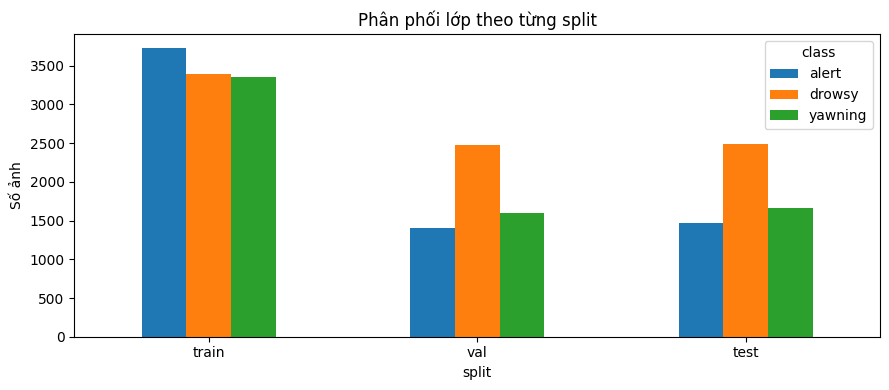

In [30]:
DRIVE_CNN_DATASET_DIR = globals().get(
    "DRIVE_CNN_DATASET_DIR", CNN_DATASET_DIR
)
LOCAL_CNN_DATASET_DIR = Path("/content/cnn_dataset")
LOCAL_READY_MARKER = LOCAL_CNN_DATASET_DIR / "_cnn_dataset_ready.json"

if not LOCAL_READY_MARKER.is_file():
    print("Đang chép cnn_dataset từ Drive về ổ local...", flush=True)
    # copytree thực tế nhanh hơn đáng kể so với việc Python kiểm tra/copy từng ảnh.
    # Nếu runtime ngắt trước khi marker được tạo, lần chạy sau sẽ chép lại an toàn.
    shutil.copytree(
        DRIVE_CNN_DATASET_DIR,
        LOCAL_CNN_DATASET_DIR,
        dirs_exist_ok=True,
    )
    LOCAL_READY_MARKER.write_text(
        json.dumps({"source": str(DRIVE_CNN_DATASET_DIR)}), encoding="utf-8"
    )
    print("Đã chép xong dataset local.", flush=True)
else:
    print("Dataset local đã tồn tại và hoàn tất; bỏ qua chép.", flush=True)

CNN_DATASET_DIR = LOCAL_CNN_DATASET_DIR
print("Dataset dùng để train:", CNN_DATASET_DIR, flush=True)

distribution_rows = []
for split in SPLITS:
    for class_name in CLASS_NAMES:
        class_dir = CNN_DATASET_DIR / split / class_name
        count = sum(
            item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
            for item in class_dir.iterdir()
        )
        if count == 0:
            raise RuntimeError(f"Không có ảnh trong {class_dir}")
        distribution_rows.append({
            "split": split,
            "class": class_name,
            "count": count,
        })

distribution = pd.DataFrame(distribution_rows)
distribution_table = distribution.pivot(
    index="split", columns="class", values="count"
).loc[list(SPLITS), CLASS_NAMES]
display(distribution_table)
distribution_table.plot(kind="bar", figsize=(9, 4), rot=0)
plt.title("Phân phối lớp theo từng split")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()


In [35]:
from pathlib import Path
import shutil

DRIVE_CNN = Path(
    "/content/drive/MyDrive/programming/nckh/"
    "driver_drowsiness/cnn_dataset"
)
LOCAL_CNN = Path("/content/cnn_dataset")

expected_train = {
    "alert": 9849,
    "drowsy": 13918,
    "yawning": 9598,
}

drive_counts = {
    class_name: sum(file.is_file() for file in (DRIVE_CNN / "train" / class_name).iterdir())
    for class_name in expected_train
}

print("Số ảnh train trực tiếp trên Drive:", drive_counts)

if drive_counts != expected_train:
    raise RuntimeError(
        "cnn_dataset trên Drive cũng đang thiếu. "
        "Chưa được chép sang local hoặc train tiếp."
    )

if LOCAL_CNN.exists():
    print("Đang xóa bản local bị thiếu...")
    shutil.rmtree(LOCAL_CNN)

print("Đang chép lại dữ liệu đầy đủ từ Drive...")
shutil.copytree(DRIVE_CNN, LOCAL_CNN)

CNN_DATASET_DIR = LOCAL_CNN
print("Đã chép xong:", CNN_DATASET_DIR)

Số ảnh train trực tiếp trên Drive: {'alert': 9849, 'drowsy': 13918, 'yawning': 9598}
Đang xóa bản local bị thiếu...
Đang chép lại dữ liệu đầy đủ từ Drive...
Đã chép xong: /content/cnn_dataset


## 7. Chuẩn bị dữ liệu cho việc học và kiểm tra

**Phần kỹ thuật:** Dùng `tf.keras.utils.image_dataset_from_directory` để tạo `train_ds`, `val_ds`, `test_ds`, cố định class order và tính `class_weight` tự động nhằm giảm ảnh hưởng của dữ liệu mất cân bằng.


In [36]:
from time import monotonic

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Bắt đầu kiểm tra việc đọc toàn bộ train dataset...")

probe_ds = tf.keras.utils.image_dataset_from_directory(
    CNN_DATASET_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=SEED,
).prefetch(1)

started_at = monotonic()

for batch_number, (images, labels) in enumerate(probe_ds, start=1):
    if batch_number % 25 == 0:
        elapsed = monotonic() - started_at
        print(
            f"Đã đọc {batch_number}/1043 batch "
            f"| thời gian {elapsed / 60:.1f} phút",
            flush=True,
        )

print("Đã đọc thành công toàn bộ train dataset.")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Bắt đầu kiểm tra việc đọc toàn bộ train dataset...
Found 33365 files belonging to 3 classes.
Đã đọc 25/1043 batch | thời gian 0.0 phút
Đã đọc 50/1043 batch | thời gian 0.1 phút
Đã đọc 75/1043 batch | thời gian 0.1 phút
Đã đọc 100/1043 batch | thời gian 0.1 phút
Đã đọc 125/1043 batch | thời gian 0.2 phút
Đã đọc 150/1043 batch | thời gian 0.2 phút
Đã đọc 175/1043 batch | thời gian 0.3 phút
Đã đọc 200/1043 batch | thời gian 0.3 phút
Đã đọc 225/1043 batch | thời gian 0.3 phút
Đã đọc 250/1043 batch | thời gian 0.4 phút
Đã đọc 275/1043 batch | thời gian 0.4 phút
Đã đọc 300/1043 batch | thời gian 0.4 phút
Đã đọc 325/1043 batch | thời gian 0.5 phút
Đã đọc 350/1043 batch | thời gian 0.5 phút
Đã đọc 375/1043 batch | thời gian 0.5 phút
Đã đọc 400/1043 batch | thời gian 0.6 phút
Đã đọc 425/1043 batch | thời gian 0.6 phút
Đã đọc 450/1043 batch | thời gian 0.6 phút
Đã đọc 475/1043 batch | thời gian 0.7 phút
Đã đọc 500/1043 batch

In [37]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


def load_split(split: str, shuffle: bool):
    return tf.keras.utils.image_dataset_from_directory(
        CNN_DATASET_DIR / split,
        labels="inferred",
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
    )


train_ds = load_split("train", shuffle=True)
val_ds = load_split("val", shuffle=False)
test_ds = load_split("test", shuffle=False)

autotune = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(1)
val_ds = val_ds.prefetch(1)
test_ds = test_ds.prefetch(1)

train_counts = distribution_table.loc["train"].to_numpy(dtype=np.float64)
total_train = train_counts.sum()
class_weights = {
    index: total_train / (len(CLASS_NAMES) * count)
    for index, count in enumerate(train_counts)
}
print("Thứ tự class:", CLASS_NAMES)
print("Class weights:", class_weights)


Found 33365 files belonging to 3 classes.
Found 5477 files belonging to 3 classes.
Found 5627 files belonging to 3 classes.
Thứ tự class: ['alert', 'drowsy', 'yawning']
Class weights: {0: np.float64(0.9372875290749687), 1: np.float64(1.0283667059285433), 2: np.float64(1.0409339294585196)}


## 8. Tạo bộ não nhận diện hình ảnh

**Phần kỹ thuật:** Dùng transfer learning với MobileNetV2 pretrained trên ImageNet, thêm data augmentation, lớp `Rescaling` về khoảng `[-1, 1]`, Global Average Pooling, Dense, Dropout và đầu ra Softmax ba lớp.


In [38]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
x = data_augmentation(inputs)
# MobileNetV2 nhận dữ liệu trong khoảng [-1, 1].
x = layers.Rescaling(1.0 / 127.5, offset=-1, name="mobilenet_preprocess")(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", name="state")(x)

model = keras.Model(inputs, outputs, name="driver_drowsiness_mobilenetv2")
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)
model.summary()


Model: "driver_drowsiness_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ state (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 9. Cho mô hình học cách phân biệt ba trạng thái

**Phần kỹ thuật:** Ở stage 1, đóng băng backbone MobileNetV2 và chỉ huấn luyện classification head. Dùng `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint` và `class_weight`.


In [39]:
def make_callbacks(checkpoint_path: Path, patience: int):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=max(2, patience // 2),
            min_lr=1e-7,
        ),
        keras.callbacks.ModelCheckpoint(
            str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]


history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=make_callbacks(STAGE1_CHECKPOINT, patience=6),
)


Epoch 1/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 114s 104ms/step - accuracy: 0.7117 - loss: 0.7732 - val_accuracy: 0.7849 - val_loss: 0.6433 - learning_rate: 1.0000e-04
Epoch 2/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 130s 93ms/step - accuracy: 0.7891 - loss: 0.6576 - val_accuracy: 0.8105 - val_loss: 0.6063 - learning_rate: 1.0000e-04
Epoch 3/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 144s 94ms/step - accuracy: 0.8123 - loss: 0.6248 - val_accuracy: 0.8203 - val_loss: 0.5881 - learning_rate: 1.0000e-04
Epoch 4/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 98s 94ms/step - accuracy: 0.8244 - loss: 0.6053 - val_accuracy: 0.8278 - val_loss: 0.5765 - learning_rate: 1.0000e-04
Epoch 5/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 105s 100ms/step - accuracy: 0.8297 - loss: 0.5939 - val_accuracy: 0.8349 - val_loss: 0.5689 - learning_rate: 1.0000e-04
Epoch 6/20
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 106s 101ms/step - accuracy: 0.8355 - loss: 0.5818 - val_accuracy: 0.8415 - val_loss: 0.5595 - learning_rate: 1.0000e-04
Epoch 7/20
1043/1043 ━━━━━━━━━━━

## 10. Cho mô hình học kỹ hơn từ bộ ảnh của dự án

**Phần kỹ thuật:** Fine-tuning 30 layer cuối của MobileNetV2 với learning rate nhỏ `1e-5`; các layer Batch Normalization vẫn được đóng băng để tránh làm mất ổn định trọng số pretrained.


In [40]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    # Giữ BatchNorm ổn định khi batch size nhỏ.
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=make_callbacks(FINETUNE_CHECKPOINT, patience=4),
)


Epoch 1/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 116s 105ms/step - accuracy: 0.8756 - loss: 0.5121 - val_accuracy: 0.8726 - val_loss: 0.5101 - learning_rate: 1.0000e-05
Epoch 2/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 107s 102ms/step - accuracy: 0.8797 - loss: 0.5020 - val_accuracy: 0.8811 - val_loss: 0.4980 - learning_rate: 1.0000e-05
Epoch 3/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 101s 97ms/step - accuracy: 0.8853 - loss: 0.4964 - val_accuracy: 0.8757 - val_loss: 0.4973 - learning_rate: 1.0000e-05
Epoch 4/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 109s 104ms/step - accuracy: 0.8892 - loss: 0.4899 - val_accuracy: 0.8826 - val_loss: 0.4899 - learning_rate: 1.0000e-05
Epoch 5/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 108s 104ms/step - accuracy: 0.8931 - loss: 0.4845 - val_accuracy: 0.8897 - val_loss: 0.4846 - learning_rate: 1.0000e-05
Epoch 6/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 103s 99ms/step - accuracy: 0.8963 - loss: 0.4804 - val_accuracy: 0.8925 - val_loss: 0.4794 - learning_rate: 1.0000e-05
Epoch 7/10
1043/1043 ━━━━━━━━━

## 11. Kiểm tra mô hình đoán đúng đến đâu

**Phần kỹ thuật:** Đánh giá trên `test_ds` độc lập bằng loss, accuracy, precision, recall, F1-score và confusion matrix; đồng thời vẽ lịch sử train/validation để kiểm tra overfitting.


176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.8927 - loss: 0.4707
Test loss: 0.4707
Test accuracy: 0.8927
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step
              precision    recall  f1-score   support

       alert     0.8560    0.8316    0.8437      1473
      drowsy     0.9624    0.9364    0.9492      2486
     yawning     0.8272    0.8813    0.8534      1668

    accuracy                         0.8927      5627
   macro avg     0.8819    0.8831    0.8821      5627
weighted avg     0.8945    0.8927    0.8932      5627



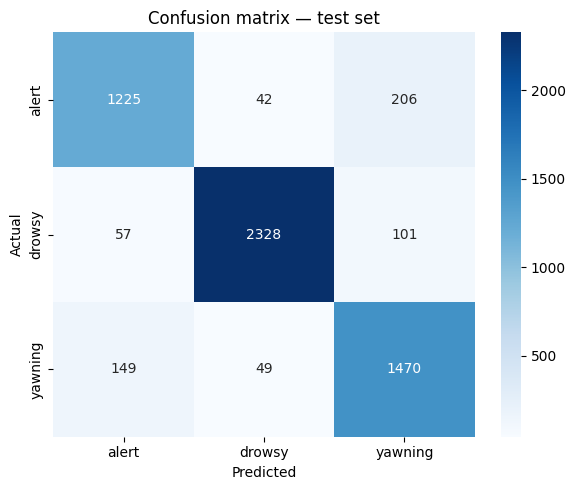

In [41]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()


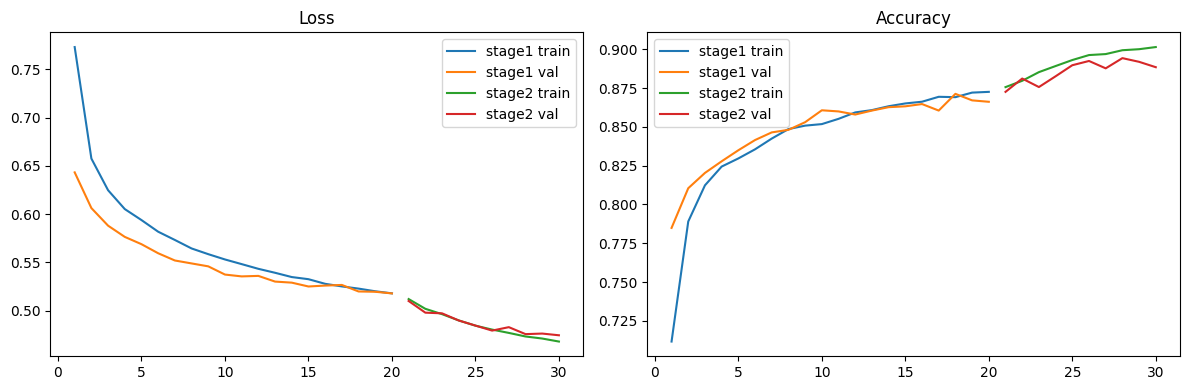

In [42]:
stage1_epochs = range(1, len(history_stage1.history["loss"]) + 1)
stage2_start = len(history_stage1.history["loss"]) + 1
stage2_epochs = range(
    stage2_start,
    stage2_start + len(history_stage2.history["loss"]),
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(stage1_epochs, history_stage1.history["loss"], label="stage1 train")
plt.plot(stage1_epochs, history_stage1.history["val_loss"], label="stage1 val")
plt.plot(stage2_epochs, history_stage2.history["loss"], label="stage2 train")
plt.plot(stage2_epochs, history_stage2.history["val_loss"], label="stage2 val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(stage1_epochs, history_stage1.history["accuracy"], label="stage1 train")
plt.plot(stage1_epochs, history_stage1.history["val_accuracy"], label="stage1 val")
plt.plot(stage2_epochs, history_stage2.history["accuracy"], label="stage2 train")
plt.plot(stage2_epochs, history_stage2.history["val_accuracy"], label="stage2 val")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Lưu kết quả để ứng dụng sử dụng

**Phần kỹ thuật:** Xuất model ở cả định dạng `.keras` và `.h5`, lưu checkpoint tốt nhất và tạo `class_names.json` mô tả class order, input size, RGB color space và preprocessing.


In [43]:
model.save(str(FINAL_KERAS_PATH))
model.save(str(MODEL_PATH))  # Giữ định dạng .h5 để tương thích với app.py hiện tại.

class_metadata = {
    "class_names": CLASS_NAMES,
    "class_to_index": {
        class_name: index for index, class_name in enumerate(CLASS_NAMES)
    },
    "input_size": list(IMAGE_SIZE),
    "input_color": "RGB",
    "input_range": [0, 255],
    "preprocessing": "Embedded Rescaling to [-1, 1]",
}
CLASS_MAP_PATH.write_text(
    json.dumps(class_metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Đã lưu Keras model:", FINAL_KERAS_PATH)
print("Đã lưu H5 model:", MODEL_PATH)
print("Đã lưu metadata:", CLASS_MAP_PATH)


Đã lưu Keras model: /content/drive/MyDrive/programming/nckh/Real-time-driver-drowsiness-detection/driver_drowsiness_cnn.keras
Đã lưu H5 model: /content/drive/MyDrive/programming/nckh/Real-time-driver-drowsiness-detection/driver_drowsiness_cnn.h5
Đã lưu metadata: /content/drive/MyDrive/programming/nckh/Real-time-driver-drowsiness-detection/class_names.json


## Sau khi dạy mô hình xong

**Phần kỹ thuật:** Model đã chứa lớp chuẩn hóa MobileNetV2. Khi cập nhật `app.py`, frame đầu vào phải được đổi từ BGR sang RGB, resize về `224×224` và giữ pixel trong khoảng `0–255`; không chia thêm cho `255`.
